# Imports

In [7]:
import os
import anndata
import numpy as np
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import RobustScaler, StandardScaler
from Functions import get_folder_names, CalculateOutgrowth, transform_features, plate_bias_overview, save_adata

# User Input

In [2]:
load_dir = "/tungstenfs/scratch/gliberal/Users/kahnmaur/2_Analysis/1_Microscopy/0_Main/005-64_ERBBi5/2_Results/2_FeaturesFiltered.h5ad"
save_dir = os.path.join(os.path.sep,*get_folder_names(load_dir)[:-1]) # Does not have to be changed if working with folder setup from Feature Extraction script
plot_save_dir = save_dir.replace("2_Results","3_Plots") # Does not have to be changed if working with folder setup from Feature Extraction script

# Set up plotting parameters
fig_param = {"axes.spines.right": False,
                  "axes.spines.top": False,
                  "axes.spines.left": True,
                  "axes.spines.bottom": True,
                  "pdf.fonttype": 42,
                  "font.size": 6,
                  "axes.labelsize": 6,
                  "axes.titlesize": 8,
                  "xtick.labelsize": 6,
                  "ytick.labelsize": 6,
                  "legend.fontsize": 6}

sns.set_theme(rc = fig_param, style = "ticks")

# Load & misc

In [3]:
ad = anndata.read_h5ad(load_dir)

# Calculate outgrowth
Calculates the outgrowth information per well by taking all indicated wells in the .xls setup file into account, even if no organoids are detected during the segmentation.

In [4]:
ad = CalculateOutgrowth(ad = ad)

Reading: /tungstenfs/scratch/gliberal/Users/kahnmaur/1_Data/1_Imaging/241104_005-64_ERBB5/PlateSetup_EB3.xlsx
Reading: /tungstenfs/scratch/gliberal/Users/kahnmaur/1_Data/1_Imaging/241104_005-64_ERBB5/PlateSetup_EBBA3.xlsx
Reading: /tungstenfs/scratch/gliberal/Users/kahnmaur/1_Data/1_Imaging/241104_005-64_ERBB5/PlateSetup_EB2.xlsx
Reading: /tungstenfs/scratch/gliberal/Users/kahnmaur/1_Data/1_Imaging/241104_005-64_ERBB5/PlateSetup_EBBA4.xlsx
Reading: /tungstenfs/scratch/gliberal/Users/kahnmaur/1_Data/1_Imaging/241104_005-64_ERBB5/PlateSetup_EB1.xlsx
Reading: /tungstenfs/scratch/gliberal/Users/kahnmaur/1_Data/1_Imaging/241104_005-64_ERBB5/PlateSetup_EBBA2.xlsx
Reading: /tungstenfs/scratch/gliberal/Users/kahnmaur/1_Data/1_Imaging/241104_005-64_ERBB5/PlateSetup_EBBA1.xlsx
Reading: /tungstenfs/scratch/gliberal/Users/kahnmaur/1_Data/1_Imaging/241104_005-64_ERBB5/PlateSetup_EB4.xlsx


Plate-Barcode: EB1


,02,03,04,05,06,07,08,09,10,11
B,"[Ctrl, AB1, EB, D10]","[Ctrl, AB1, EB, D10]","[Gefitinib, AB1, EB, D10]","[Gefitinib, AB1, EB, D10]","[LY294002, AB1, EB, D10]","[LY294002, AB1, EB, D10]","[Lumretuzumab, AB1, EB, D10]","[Lumretuzumab, AB1, EB, D10]","[Ctrl, AB1, EB, D10]","[Ctrl, AB1, EB, D10]"
C,"[Ctrl, AB1, EB, D10]","[Ctrl, AB1, EB, D10]","[Gefitinib, AB1, EB, D10]","[Gefitinib, AB1, EB, D10]","[LY294002, AB1, EB, D10]","[LY294002, AB1, EB, D10]","[Lumretuzumab, AB1, EB, D10]","[Lumretuzumab, AB1, EB, D10]","[Ctrl, AB1, EB, D10]","[Ctrl, AB1, EB, D10]"
D,"[Ctrl, AB2, EB, D10]","[Ctrl, AB2, EB, D10]","[Gefitinib, AB2, EB, D10]","[Gefitinib, AB2, EB, D10]","[LY294002, AB2, EB, D10]","[LY294002, AB2, EB, D10]","[Lumretuzumab, AB2, EB, D10]","[Lumretuzumab, AB2, EB, D10]","[Ctrl, AB2, EB, D10]","[Ctrl, AB2, EB, D10]"
E,"[Ctrl, AB2, EB, D10]","[Ctrl, AB2, EB, D10]","[Gefitinib, AB2, EB, D10]","[Gefitinib, AB2, EB, D10]","[LY294002, AB2, EB, D10]","[LY294002, AB2, EB, D10]","[Lumretuzumab, AB2, EB, D10]","[Lumretuzumab, AB2, EB, D10]","[Ctrl, AB2, EB, D10]","[Ctrl, AB2, EB, D10]"
F,"[Ctrl, AB3, EB, D10]","[Ctrl, AB3, EB, D10]","[Gefitinib, AB3, EB, D10]","[Gefitinib, AB3, EB, D10]","[LY294002, AB3, EB, D10]","[LY294002, AB3, EB, D10]","[Lumretuzumab, AB3, EB, D10]","[Lumretuzumab, AB3, EB, D10]","[Ctrl, AB3, EB, D10]","[Ctrl, AB3, EB, D10]"
G,"[Ctrl, AB3, EB, D10]","[Ctrl, AB3, EB, D10]","[Gefitinib, AB3, EB, D10]","[Gefitinib, AB3, EB, D10]","[LY294002, AB3, EB, D10]","[LY294002, AB3, EB, D10]","[Lumretuzumab, AB3, EB, D10]","[Lumretuzumab, AB3, EB, D10]","[Ctrl, AB3, EB, D10]","[Ctrl, AB3, EB, D10]"




Plate-Barcode: EB2


,02,03,04,05,06,07,08,09,10,11
B,"[Ctrl, AB1, EB, D10]","[Ctrl, AB1, EB, D10]","[Gefitinib, AB1, EB, D10]","[Gefitinib, AB1, EB, D10]","[LY294002, AB1, EB, D10]","[LY294002, AB1, EB, D10]","[Lumretuzumab, AB1, EB, D10]","[Lumretuzumab, AB1, EB, D10]","[Ctrl, AB1, EB, D10]","[Ctrl, AB1, EB, D10]"
C,"[Ctrl, AB1, EB, D10]","[Ctrl, AB1, EB, D10]","[Gefitinib, AB1, EB, D10]","[Gefitinib, AB1, EB, D10]","[LY294002, AB1, EB, D10]","[LY294002, AB1, EB, D10]","[Lumretuzumab, AB1, EB, D10]","[Lumretuzumab, AB1, EB, D10]","[Ctrl, AB1, EB, D10]","[Ctrl, AB1, EB, D10]"
D,"[Ctrl, AB2, EB, D10]","[Ctrl, AB2, EB, D10]","[Gefitinib, AB2, EB, D10]","[Gefitinib, AB2, EB, D10]","[LY294002, AB2, EB, D10]","[LY294002, AB2, EB, D10]","[Lumretuzumab, AB2, EB, D10]","[Lumretuzumab, AB2, EB, D10]","[Ctrl, AB2, EB, D10]","[Ctrl, AB2, EB, D10]"
E,"[Ctrl, AB2, EB, D10]","[Ctrl, AB2, EB, D10]","[Gefitinib, AB2, EB, D10]","[Gefitinib, AB2, EB, D10]","[LY294002, AB2, EB, D10]","[LY294002, AB2, EB, D10]","[Lumretuzumab, AB2, EB, D10]","[Lumretuzumab, AB2, EB, D10]","[Ctrl, AB2, EB, D10]","[Ctrl, AB2, EB, D10]"
F,"[Ctrl, AB3, EB, D10]","[Ctrl, AB3, EB, D10]","[Gefitinib, AB3, EB, D10]","[Gefitinib, AB3, EB, D10]","[LY294002, AB3, EB, D10]","[LY294002, AB3, EB, D10]","[Lumretuzumab, AB3, EB, D10]","[Lumretuzumab, AB3, EB, D10]","[Ctrl, AB3, EB, D10]","[Ctrl, AB3, EB, D10]"
G,"[Ctrl, AB3, EB, D10]","[Ctrl, AB3, EB, D10]","[Gefitinib, AB3, EB, D10]","[Gefitinib, AB3, EB, D10]","[LY294002, AB3, EB, D10]","[LY294002, AB3, EB, D10]","[Lumretuzumab, AB3, EB, D10]","[Lumretuzumab, AB3, EB, D10]","[Ctrl, AB3, EB, D10]","[Ctrl, AB3, EB, D10]"




Plate-Barcode: EB3


...

,02,03,04,05,06,07,08,09,10,11
B,"[Ctrl, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]","[Gefitinib, AB4, EBBA, D12]","[Gefitinib, AB4, EBBA, D12]","[LY294002, AB4, EBBA, D12]","[LY294002, AB4, EBBA, D12]","[Lapatinib, AB4, EBBA, D12]","[Lapatinib, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]"
C,"[Ctrl, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]","[Gefitinib, AB4, EBBA, D12]","[Gefitinib, AB4, EBBA, D12]","[LY294002, AB4, EBBA, D12]","[LY294002, AB4, EBBA, D12]","[Lapatinib, AB4, EBBA, D12]","[Lapatinib, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]"
D,"[Ctrl, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]","[Gefitinib, AB5, EBBA, D12]","[Gefitinib, AB5, EBBA, D12]","[LY294002, AB5, EBBA, D12]","[LY294002, AB5, EBBA, D12]","[Lapatinib, AB5, EBBA, D12]","[Lapatinib, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]"
E,"[Ctrl, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]","[Gefitinib, AB5, EBBA, D12]","[Gefitinib, AB5, EBBA, D12]","[LY294002, AB5, EBBA, D12]","[LY294002, AB5, EBBA, D12]","[Lapatinib, AB5, EBBA, D12]","[Lapatinib, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]"
F,"[Ctrl, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]","[Gefitinib, AB6, EBBA, D12]","[Gefitinib, AB6, EBBA, D12]","[LY294002, AB6, EBBA, D12]","[LY294002, AB6, EBBA, D12]","[Lapatinib, AB6, EBBA, D12]","[Lapatinib, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]"
G,"[Ctrl, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]","[Gefitinib, AB6, EBBA, D12]","[Gefitinib, AB6, EBBA, D12]","[LY294002, AB6, EBBA, D12]","[LY294002, AB6, EBBA, D12]","[Lapatinib, AB6, EBBA, D12]","[Lapatinib, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]"




Plate-Barcode: EBBA3


,02,03,04,05,06,07,08,09,10,11
B,"[Ctrl, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]","[Gefitinib, AB4, EBBA, D12]","[Gefitinib, AB4, EBBA, D12]","[LY294002, AB4, EBBA, D12]","[LY294002, AB4, EBBA, D12]","[Lapatinib, AB4, EBBA, D12]","[Lapatinib, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]"
C,"[Ctrl, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]","[Gefitinib, AB4, EBBA, D12]","[Gefitinib, AB4, EBBA, D12]","[LY294002, AB4, EBBA, D12]","[LY294002, AB4, EBBA, D12]","[Lapatinib, AB4, EBBA, D12]","[Lapatinib, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]"
D,"[Ctrl, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]","[Gefitinib, AB5, EBBA, D12]","[Gefitinib, AB5, EBBA, D12]","[LY294002, AB5, EBBA, D12]","[LY294002, AB5, EBBA, D12]","[Lapatinib, AB5, EBBA, D12]","[Lapatinib, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]"
E,"[Ctrl, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]","[Gefitinib, AB5, EBBA, D12]","[Gefitinib, AB5, EBBA, D12]","[LY294002, AB5, EBBA, D12]","[LY294002, AB5, EBBA, D12]","[Lapatinib, AB5, EBBA, D12]","[Lapatinib, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]"
F,"[Ctrl, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]","[Gefitinib, AB6, EBBA, D12]","[Gefitinib, AB6, EBBA, D12]","[LY294002, AB6, EBBA, D12]","[LY294002, AB6, EBBA, D12]","[Lapatinib, AB6, EBBA, D12]","[Lapatinib, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]"
G,"[Ctrl, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]","[Gefitinib, AB6, EBBA, D12]","[Gefitinib, AB6, EBBA, D12]","[LY294002, AB6, EBBA, D12]","[LY294002, AB6, EBBA, D12]","[Lapatinib, AB6, EBBA, D12]","[Lapatinib, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]"




Plate-Barcode: EBBA4


,02,03,04,05,06,07,08,09,10,11
B,"[Ctrl, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]","[Gefitinib, AB4, EBBA, D12]","[Gefitinib, AB4, EBBA, D12]","[LY294002, AB4, EBBA, D12]","[LY294002, AB4, EBBA, D12]","[Lapatinib, AB4, EBBA, D12]","[Lapatinib, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]"
C,"[Ctrl, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]","[Gefitinib, AB4, EBBA, D12]","[Gefitinib, AB4, EBBA, D12]","[LY294002, AB4, EBBA, D12]","[LY294002, AB4, EBBA, D12]","[Lapatinib, AB4, EBBA, D12]","[Lapatinib, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]","[Ctrl, AB4, EBBA, D12]"
D,"[Ctrl, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]","[Gefitinib, AB5, EBBA, D12]","[Gefitinib, AB5, EBBA, D12]","[LY294002, AB5, EBBA, D12]","[LY294002, AB5, EBBA, D12]","[Lapatinib, AB5, EBBA, D12]","[Lapatinib, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]"
E,"[Ctrl, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]","[Gefitinib, AB5, EBBA, D12]","[Gefitinib, AB5, EBBA, D12]","[LY294002, AB5, EBBA, D12]","[LY294002, AB5, EBBA, D12]","[Lapatinib, AB5, EBBA, D12]","[Lapatinib, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]","[Ctrl, AB5, EBBA, D12]"
F,"[Ctrl, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]","[Gefitinib, AB6, EBBA, D12]","[Gefitinib, AB6, EBBA, D12]","[LY294002, AB6, EBBA, D12]","[LY294002, AB6, EBBA, D12]","[Lapatinib, AB6, EBBA, D12]","[Lapatinib, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]"
G,"[Ctrl, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]","[Gefitinib, AB6, EBBA, D12]","[Gefitinib, AB6, EBBA, D12]","[LY294002, AB6, EBBA, D12]","[LY294002, AB6, EBBA, D12]","[Lapatinib, AB6, EBBA, D12]","[Lapatinib, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]","[Ctrl, AB6, EBBA, D12]"


# Normalization
Performs z-normalisation and robust scaling

In [5]:
def normalize_groups(adata, group_by, control=None):
    """
    Normalize data in an AnnData object by groups, applying log1p transformation
    to area-associated features, and then creating separate layers for robust scaling
    and z-normalization.

    This function performs the following steps:
    1. Groups the data based on specified grouping variables.
    2. Applies log1p transformation to area-associated features.
    3. Performs robust scaling on each group, optionally using a control group.
    4. Performs z-normalization (standardization) on each group.
    5. Stores the transformed data in new layers of the AnnData object.

    Parameters:
    -----------
    adata : anndata.AnnData
        The AnnData object containing the data to be normalized.
    group_by : str or list of str
        The column name(s) in adata.obs to group the data by.
    control : dict, optional
        A dictionary specifying the control group for normalization.
        The key is the column name, and the value is the control group value.
        If None, each group is normalized independently.

    Returns:
    --------
    anndata.AnnData
        The input AnnData object with additional layers:
        - 'log1p': log1p transformed data for area-associated features
        - 'robust_scaled': robustly scaled data
        - 'z_normalized': z-normalized (standardized) data

    Notes:
    ------
    - Area-associated features are identified by containing 'area', 'moments',
      or 'potency' in their names.
    - The function uses RobustScaler and StandardScaler from sklearn for scaling.
    """
        
    if isinstance(group_by, str):
        group_by = [group_by]

    # Get unique combinations of grouping variables
    groups = adata.obs.groupby(group_by).groups

    # Create new arrays to store the normalized data
    robust_normalized_data = np.zeros_like(adata.X)
    z_normalized_data = np.zeros_like(adata.X)

    # get list of area-associated features for transformation
    to_transform = [x for x in list(adata.var_names) if any(y in x for y in ["area", "moments", "potency"])]
    to_transform = [x for x in to_transform if not any(y in x for y in ["ratio"])]
    
    # Extract DF to work with from AnnData
    df = adata.to_df().copy()

    # log1p transform subset
    df[to_transform] = np.log1p(df[to_transform])
    
    # Save as layer
    adata.layers["log1p"] = df.values

    if control is not None:
        control_key, control_value = list(control.items())[0]

    # Perform scaling for each group
    for group, indices in groups.items():
        int_indices = adata.obs_names.get_indexer(indices)
        group_data = adata.layers["log1p"][int_indices]

        if control is None:
            robust_scaler = RobustScaler().fit(group_data)
            z_scaler = StandardScaler().fit(group_data)
        else:
            control_mask = adata.obs.loc[indices, control_key] == control_value
            control_data = group_data[control_mask]
            
            # Fit scalers on control data
            robust_scaler = RobustScaler().fit(control_data)
            z_scaler = StandardScaler().fit(control_data)
        
        # Transform all group data
        robust_scaled_data = robust_scaler.transform(group_data)
        z_normalized = z_scaler.transform(group_data)

        robust_normalized_data[int_indices] = robust_scaled_data
        z_normalized_data[int_indices] = z_normalized

    # Add the normalized data as new layers
    adata.layers["robust_scaled"] = robust_normalized_data
    adata.layers["z_normalized"] = z_normalized_data

    return adata


In [15]:
ad = normalize_groups(ad, "Barcode", control={"Medium": "Ctrl"})

/tungstenfs/scratch/gliberal/Users/kahnmaur/3_Programming/2_Miniconda/miniconda3/envs/HT_org_analysis/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/tungstenfs/scratch/gliberal/Users/kahnmaur/3_Programming/2_Miniconda/miniconda3/envs/HT_org_analysis/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1556: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
/tungstenfs/scratch/gliberal/Users/kahnmaur/3_Programming/2_Miniconda/miniconda3/envs/HT_org_analysis/lib/python3.11/site-packages/sklearn/utils/extmath.py:1047: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/tungstenfs/scratch/gliberal/Users/kahnmaur/3_Programming/2_Miniconda/miniconda3/envs/HT_org_analysis/lib/python3.11/site-packages/sklearn/utils/extmath.py:1052: RuntimeWarning: invalid value encountered in di

# Plate overview to check for positional bias
Generate heatmaps illustrating plate bias based on specified features and experimental conditions. Values are z-scores of well averages normalized within conditions.

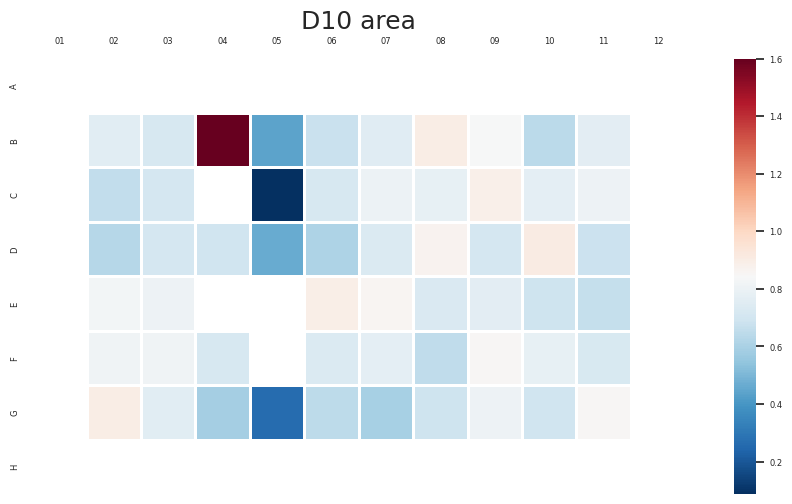

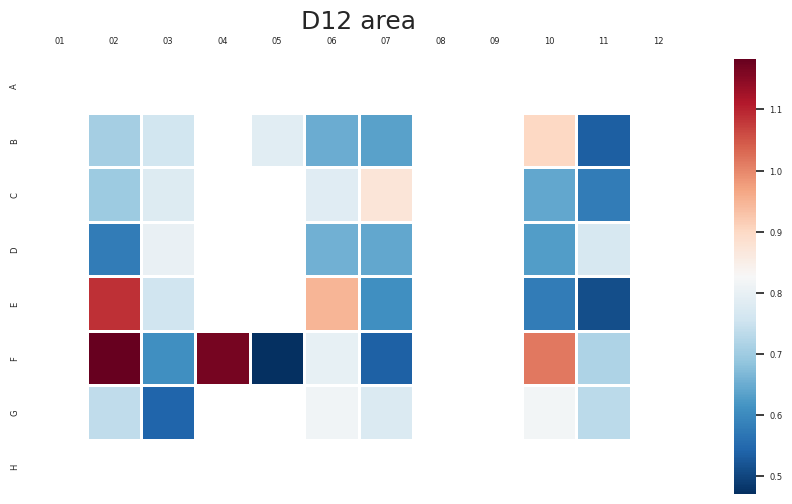

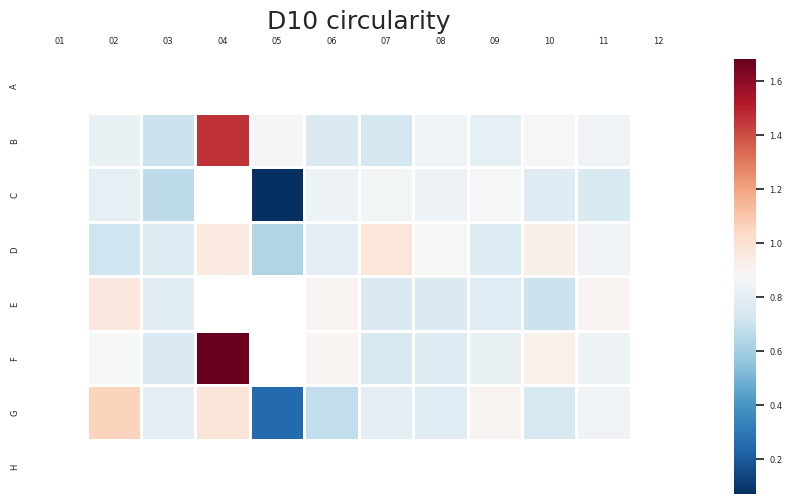

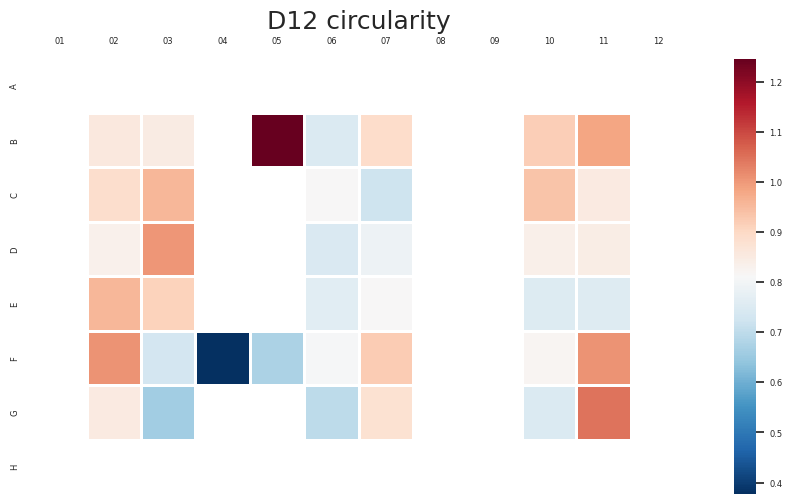

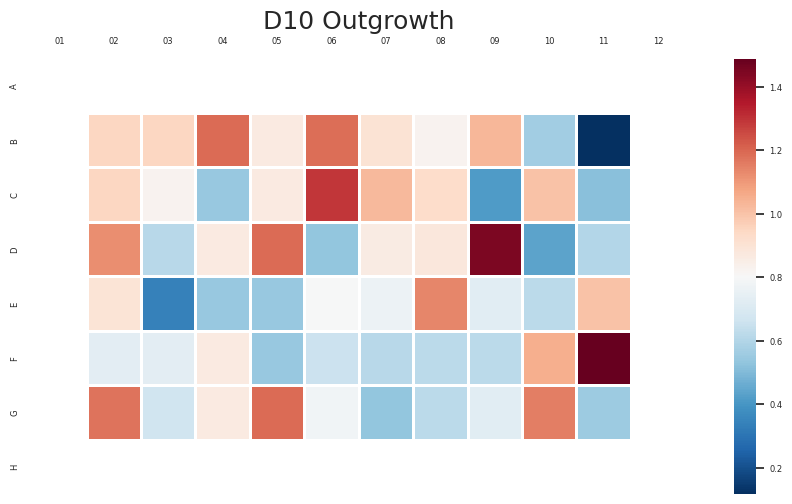

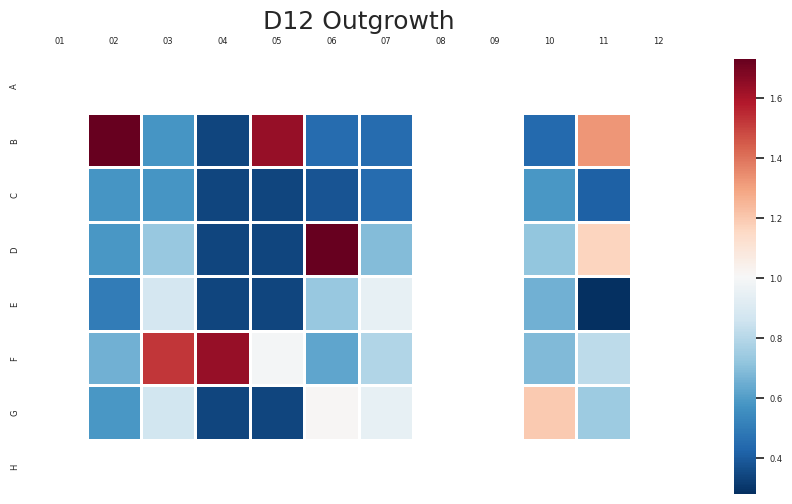

In [16]:
plate_bias_overview(plt_features = ["area", "circularity"], 
                    ad = ad,
                    plate_size = 96 # 384 or 96 plate setup
                   )

# Save AD

In [17]:
save_adata(save_dir, "3_QC", ad)

Saved as:
/tungstenfs/scratch/gliberal/Users/kahnmaur/2_Analysis/1_Microscopy/0_Main/005-64_ERBBi5/2_Results/3_QC1.h5ad
